<a href="https://colab.research.google.com/github/tsukaharuki/IMD-Internship-Homework/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **情報分析概論2026 Homework 1** (20 points)

## **パターン分析**

頻出パターンマイニング（Frequent Pattern Mining）は、大規模なデータセットの中から頻繁に出現するパターンや関係、または関連性を発見するための、データマイニングにおける基本的な手法です。
この手法の目的は、データセット内で一緒に出現することの多いアイテムやイベント、データの部分集合などを特定することにあります。


Frequent Pattern Mining is a fundamental data mining technique used to discover frequently occurring patterns, relationships, or associations within large datasets. The goal of frequent pattern mining is to identify items, events, or subsets of data that appear together frequently in the dataset.


あなたは現在、Nozamaというオンラインショッピング会社でデータアナリストとして働いています。
経営陣が商品の売上向上のための新たな戦略を立てるための参考として、現在の販売記録を分析し、有益なインサイトを導き出すよう依頼されています。

You are now working as a data analyst for an online shopping company called Nozama. You have
been asked to mine the current sales records to derive insights that can help the management
develop new strategies to improve the product sales.


データセットは「record.csv」というファイルに含まれており、以下の列が含まれています：

The dataset can be found in record.csv. It contains the following columns:

InvoiceNo: The ID of the transaction (取引ID)

StockCode: The ID of the item (商品ID)

Description: The name of the item (商品の名称)

Quantity: The number of an item bought in the
transaction (取引で購入された商品の数量)

InvoiceDate: The date of the transaction (取引の日付)

UnitPrice: The unit price of the item (商品の単価)

CustomerID: The ID of customer (顧客のID)

**こちらにお名前と学生IDをご記入ください。**

**Please write your name and student id here.**

名前:高岡 晴玖

学生ID:26622036

In [1]:
# -- import all libraries --

# data manipulation
import pandas as pd

# data visualization
import matplotlib.pyplot as plt

# record elapsed time
import time

# save text
import numpy as np

# association rule mining
from mlxtend.frequent_patterns import apriori as mlx_apriori
!pip install efficient_apriori
from efficient_apriori import apriori as eff_apriori

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# -- upload data --
# please upload "record.csv"

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving record.csv to record.csv
User uploaded file "record.csv" with length 40249124 bytes


In [5]:
# -- load data --

# read "record.csv" as pandas DataFrame
df = pd.read_csv("record.csv")

# print types of dirty records
print("Missing values count: ")
print(df.isnull().sum())
print("\nNegative Unitprice: %d"%(df.UnitPrice.loc[df.UnitPrice <= 0].count()))
print("\nWrong Stockcodes: %d"%(df.StockCode.str.match("[^0-9]").sum()))

Missing values count: 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
dtype: int64

Negative Unitprice: 2517

Wrong Stockcodes: 2995


## **Section 1: 前処理**

以下のように、不正なレコード（dirty records）を定義します。

*   欠損値：Description=1454, CustomerID=135080;
*   単価が負の値：2517;
*   誤ったStockCode（例："BANK CHARGES"など）：2995

We define the dirty records as follows.

*   Missing values: Description=1454, CustomerID=135080;
*   Negative unitprices: 2517;
*   Wrong StockCode (like "BANK CHARGES"): 2995.

In [6]:
# -- remove the dirty records --

# drop missing values
df.dropna(inplace=True)

# drop negative Unitprice
# note that quantity can be negative because there are return services, i.e. StockCode 23843 has two transactions
# with quantity of 80885 and -80885, so eventually not even one item-23843 is given out in the two transactions.
df = df[(df['UnitPrice']>0)]

# drop wrong stockcode like "BANK CHARGES"
df = df.loc[df.StockCode.str.match("^[0-9]")]

In [9]:
# show starting date of the dataset
print("\nStarting date: {}".format(df.InvoiceDate.min()))
print("\nEnding date: {}".format(df.InvoiceDate.max()))


Starting date: 2010-12-01 08:26:00

Ending date: 2011-12-09 12:50:00


In [11]:
# show number of transactions
print("Number of transactions: %d"%(df.InvoiceNo.nunique()))

# show number of items
print("Number of items: %d"%(df.StockCode.nunique()))

print("Number of Customer: %d"%(df.CustomerID.nunique()))

Number of transactions: 21785
Number of items: 3676
Number of Customer: 4362


### **Question 1.1** (1 point):
このデータセットの終了日はいつですか？

What it the ending date of the dataset?

Ans.)2011年12月9日

### **Question 1.2** (1 point):
顧客の人数は何人ですか？

What it the number of customers?

Ans.)4362人

In [18]:
# df_1 contains only CustomerID and unique InvoiceNo
df_1 = df[['CustomerID','InvoiceNo']]
df_1.drop_duplicates('InvoiceNo', keep='first', inplace=True)
series = df_1['CustomerID'].value_counts()
print(series[17850])
print(series.max())
print(series.idxmax())

35
242
14911.0


### **Question 1.3** (2 points):
顧客ID「17850」が行った取引の件数はいくつですか？

What is the number of transactions that customer ID 17850 has made?

Ans.) 35件

### **Question 1.4** (2 points):
一番多くの取引を行った顧客は誰ですか？

Which customer has made the most transactions?

Ans.) ID:14911の人

In [31]:
# df_2 contains only StockCode and Quantity
df_2 = df[['StockCode','Quantity']]
df_2 = df_2.groupby(['StockCode'], as_index=False)['Quantity'].sum()
print(df_2.loc[df_2['Quantity'].idxmax()])


StockCode    84077
Quantity     53215
Name: 2812, dtype: object


### **Question 1.5** (2 points):
最も売れた商品の商品IDは何ですか？（「最も売れた商品」とは、販売数量が最も多い商品と定義します）

What is the item ID of the best-seller? (We define "best-seller" as the item with the highest sales volume)

Ans.) 84077

次に、取引に関する全体的な理解を深めていきましょう。まず、1件の取引あたりに含まれるユニークな商品の個数について、ヒストグラムを作成します。

Next, let us get some general understanding about the transactions. We first make a histogram of the number of unique items per transaction.

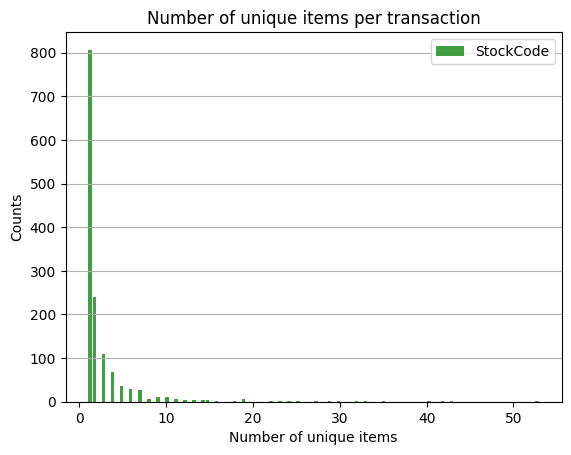

In [32]:
# --- generate the histogram ---

df_3 = df[['InvoiceNo','StockCode',]].drop_duplicates(subset=["StockCode"]).groupby(["InvoiceNo"]).agg("count")
df_3.plot.hist(grid=False, bins=100, rwidth=.8, facecolor='g', alpha=0.75)
plt.title('Number of unique items per transaction')
plt.xlabel('Number of unique items')
plt.ylabel('Counts')
plt.grid(axis='y', alpha=1)

### **Question 1.6** (1 point):
ほとんどの取引で、顧客は何種類の商品を購入していますか？

How many kinds if items do clients buy in most of transactions?

Ans.) 1種類

アイテムに基づいてデータをさらに分析することもできます。
以下では、サポート値が0.05を超える商品について、バープロットを作成します。

We can also explore the data based on the items. Below we make a bar plot of the items with support higher than 0.05.

['85123A']


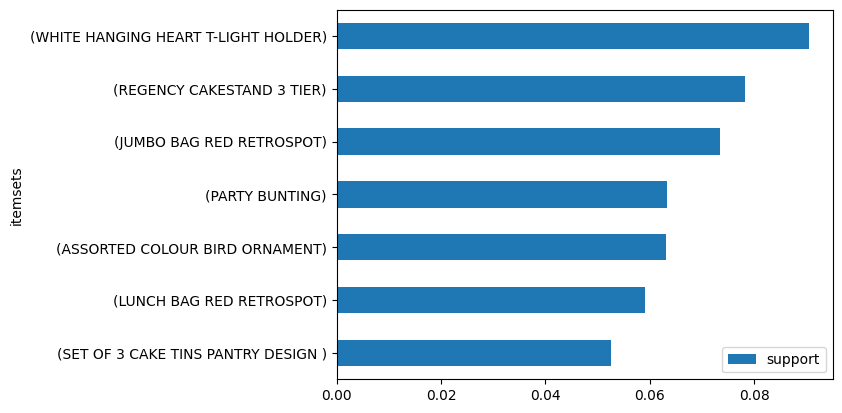

In [35]:
# --- generate the bar plot ---

df_4 = df[["InvoiceNo","Description","Quantity"]]

basket = (df_4.groupby(["InvoiceNo","Description"])["Quantity"].sum() \
            .unstack().reset_index().fillna(0).set_index("InvoiceNo")) \
            .applymap(lambda x: 0 if x <= 0 else 1)

# construct frequent itemset
freq_set = mlx_apriori(basket, min_support=0.05, use_colnames=True)
freq_set = freq_set.sort_values(["support"],ascending=True)
freq_set.plot.barh(x = 'itemsets',y = 'support')
print(df[
    df['Description'] == 'WHITE HANGING HEART T-LIGHT HOLDER']['StockCode'].unique()
)

### **Question 1.7** (1 point):
サポート値が最も高い商品は何ですか？それは1.5の質問で見つけた商品と同じですか？

What is the item with the highest support? Is it the same item that you found in Question 1.5?

Ans.) サポート値が高い商品はWHITE HANGING HEART T-LIGHT HOLDERである。また、StockCodeは85123Aなので1.5の質問で見つけた商品とは異なる。

## **Section 2: パターン分析**

### **Question 2.0** (1 point):
まず、「ブルートフォース」によるアイテムセットのカウント（すなわち、すべての可能なアイテムセットを数える方法）が現実的かどうかを考えてみましょう。 セクション1で示したように、一意のアイテム数は3676個であるため、可能なアイテムセットの総数は2^3676となります。 仮に、1秒間に2^36個のアイテムセットをカウントできるとした場合、太陽が燃え尽きる前（太陽が燃え尽きるまであと約5 × 10^9年、これは2^33年未満）に、すべてのアイテムセットをカウントし終えることができるでしょうか？


Let us first consider whether the “brute-force” counting method (i.e. counting all possible
itemsets) is feasible. In Section 1 we know that number of unique items is 3676, thus we have 2^3676 itemsets. Suppose we can count 2^36 itemsets per second. Will we complete the
counting before the sun burns out (the sun has another 5 × 10^9 < 2^33 years to burn)?

Ans.) すべてのアイテムセットをカウントするのに2^3640(s)かかる。そして、太陽が燃え尽きるまでの時間は2^33年未満なのでこれを秒に換算するとおよそ2^58(s)なのですべてのアイテムセットをカウントし終えることは不可能である。

### **Question 2.1** (1 point):
頻出パターンマイニングにおける以下の概念について説明してください：
*サポート*（support）、*信頼度*（confidence）、*リフト*（lift）。

Please explain the following concepts in frequent pattern mining: *support*, *confidence*, and *lift*.

Ans.) アソシエーションルールとしてX→Y(s,c)とする。XとYはアイテムセットとする。

サポート:トランザクションがXかつYを含む確率。記号ではsである。

信頼度:Xを含むトランザクションがYも含む確率。記号はcである。

リフト:XとYの相関関係を示し、XとYの関連が偶然かそうでないかを表す。

<参考文献>
馬 強, "情報分析概論 -パターン発見-", URL:https://moodle.cis.kit.ac.jp/pluginfile.php/976259/mod_resource/content/1/%E6%83%85%E5%A0%B1%E5%88%86%E6%9E%90%E6%A6%82%E8%AB%96-PatternDiscover-JP.pdf, 参照日:2026年4月14日

In [37]:
df_5 = df[["InvoiceNo","Description"]]
basket_set = df_5.groupby("InvoiceNo").Description.apply(tuple).tolist()

次に、efficient-apriori アルゴリズムを用いて、min_support=0.005、min_confidence=20%、max_length=4 で実行します。
リフト値が最も高いルールを **R1** として記録します。

Below, we run efficient-apriori with min_support=0.005, min_confidence=20%, max_length=4. We denote the generated rules with the highest lift as **R1**.

In [38]:
# --- generate R1 ---

start = time.time()
itemsets_1, rules_1 = eff_apriori(basket_set, min_support=0.005, min_confidence = 0.2, max_length = 4)
count_time = time.time() - start
# print the running time
print('Time: ', count_time, 'seconds')

# print the rules with the top-5 highest lift
print(*sorted(rules_1, key=lambda rule: -rule.lift)[0:5])

# print the total number of generated rules
len(rules_1)

Time:  7.875792503356934 seconds
{DOLLY GIRL CHILDRENS CUP} -> {DOLLY GIRL CHILDRENS BOWL} (conf: 0.810, supp: 0.005, lift: 121.624, conv: 5.215) {DOLLY GIRL CHILDRENS BOWL} -> {DOLLY GIRL CHILDRENS CUP} (conf: 0.821, supp: 0.005, lift: 121.624, conv: 5.539) {HERB MARKER PARSLEY, HERB MARKER THYME} -> {HERB MARKER BASIL, HERB MARKER CHIVES } (conf: 0.820, supp: 0.006, lift: 120.666, conv: 5.511) {HERB MARKER BASIL, HERB MARKER CHIVES } -> {HERB MARKER PARSLEY, HERB MARKER THYME} (conf: 0.953, supp: 0.006, lift: 120.666, conv: 20.976) {REGENCY TEA PLATE GREEN , ROSES REGENCY TEACUP AND SAUCER } -> {GREEN REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE ROSES } (conf: 0.791, supp: 0.006, lift: 120.480, conv: 4.750)


4925

**R1** には、以下の2つのルールが含まれていることが分かります：

{DOLLY GIRL CHILDRENS CUP} → {DOLLY GIRL CHILDRENS BOWL}

{DOLLY GIRL CHILDRENS BOWL} → {DOLLY GIRL CHILDRENS CUP}


We can see that **R1** includes two rules:

{DOLLY GIRL CHILDRENS CUP} -> {DOLLY GIRL CHILDRENS BOWL}

{DOLLY GIRL CHILDRENS BOWL} -> {DOLLY GIRL CHILDRENS CUP}.

### **Question 2.2** (2 points):
次に、min_support=0.01、min_confidence=20%、max_length=4 で efficient-apriori を実行し、リフト値が最も高いルールを **R2** として記録してください。
実行時間および **R2** を出力してください。

Run efficient-apriori with min_support=0.01, min_confidence=20%, max_length=4. Denote the generated rules with the highest lift as **R2**. Print the running time and **R2**.

実行時間: 69.21920371055603 (s)

R2 = 766.832

In [40]:
# --- generate R1 ---

start = time.time()
itemsets_2, rules_2 = eff_apriori(basket_set, min_support=0.001, min_confidence = 0.2, max_length = 4)
count_time = time.time() - start
# print the running time
print('Time: ', count_time, 'seconds')

# print the rules with the top-5 highest lift
print(*sorted(rules_2, key=lambda rule: -rule.lift)[0:5])

# print the total number of generated rules
len(rules_2)

Time:  69.21920371055603 seconds
{PINK KNITTED EGG COSY} -> {BLUE KNITTED EGG COSY} (conf: 0.880, supp: 0.001, lift: 766.832, conv: 8.324) {BLUE KNITTED EGG COSY} -> {PINK KNITTED EGG COSY} (conf: 0.880, supp: 0.001, lift: 766.832, conv: 8.324) {50'S CHRISTMAS PAPER GIFT BAG, VINTAGE CHRISTMAS GIFT BAG LARGE } -> { 50'S CHRISTMAS GIFT BAG LARGE, VINTAGE CHRISTMAS PAPER GIFT BAG} (conf: 0.815, supp: 0.001, lift: 682.721, conv: 5.394) { 50'S CHRISTMAS GIFT BAG LARGE, VINTAGE CHRISTMAS PAPER GIFT BAG} -> {50'S CHRISTMAS PAPER GIFT BAG, VINTAGE CHRISTMAS GIFT BAG LARGE } (conf: 0.846, supp: 0.001, lift: 682.721, conv: 6.492) {PANTRY HOOK TEA STRAINER } -> {PANTRY HOOK SPATULA} (conf: 0.786, supp: 0.001, lift: 658.338, conv: 4.661)


343790

### **Question 2.3** (2 points):
さらに、min_support=0.005、min_confidence=40%、max_length=4 で実行し、リフト値が最も高いルールを **R3** として記録してください。
同様に、実行時間および **R3** を出力してください。

Run efficient-apriori with min_support=0.005, min_confidence=40%, max_length=4. Denote the generated rules with the highest lift as **R3**. Print the running time and **R3**.

実行時間:8.425899982452393(s)

R3:121.624

In [41]:
# --- generate R1 ---

start = time.time()
itemsets_3, rules_3 = eff_apriori(basket_set, min_support=0.005, min_confidence = 0.4, max_length = 4)
count_time = time.time() - start
# print the running time
print('Time: ', count_time, 'seconds')

# print the rules with the top-5 highest lift
print(*sorted(rules_3, key=lambda rule: -rule.lift)[0:5])

# print the total number of generated rules
len(rules_3)

Time:  8.425899982452393 seconds
{DOLLY GIRL CHILDRENS CUP} -> {DOLLY GIRL CHILDRENS BOWL} (conf: 0.810, supp: 0.005, lift: 121.624, conv: 5.215) {DOLLY GIRL CHILDRENS BOWL} -> {DOLLY GIRL CHILDRENS CUP} (conf: 0.821, supp: 0.005, lift: 121.624, conv: 5.539) {HERB MARKER PARSLEY, HERB MARKER THYME} -> {HERB MARKER BASIL, HERB MARKER CHIVES } (conf: 0.820, supp: 0.006, lift: 120.666, conv: 5.511) {HERB MARKER BASIL, HERB MARKER CHIVES } -> {HERB MARKER PARSLEY, HERB MARKER THYME} (conf: 0.953, supp: 0.006, lift: 120.666, conv: 20.976) {REGENCY TEA PLATE GREEN , ROSES REGENCY TEACUP AND SAUCER } -> {GREEN REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE ROSES } (conf: 0.791, supp: 0.006, lift: 120.480, conv: 4.750)


2774

In [42]:
print(*sorted(rules_1, key=lambda rule: -rule.lift)[0:5])

{DOLLY GIRL CHILDRENS CUP} -> {DOLLY GIRL CHILDRENS BOWL} (conf: 0.810, supp: 0.005, lift: 121.624, conv: 5.215) {DOLLY GIRL CHILDRENS BOWL} -> {DOLLY GIRL CHILDRENS CUP} (conf: 0.821, supp: 0.005, lift: 121.624, conv: 5.539) {HERB MARKER PARSLEY, HERB MARKER THYME} -> {HERB MARKER BASIL, HERB MARKER CHIVES } (conf: 0.820, supp: 0.006, lift: 120.666, conv: 5.511) {HERB MARKER BASIL, HERB MARKER CHIVES } -> {HERB MARKER PARSLEY, HERB MARKER THYME} (conf: 0.953, supp: 0.006, lift: 120.666, conv: 20.976) {REGENCY TEA PLATE GREEN , ROSES REGENCY TEACUP AND SAUCER } -> {GREEN REGENCY TEACUP AND SAUCER, REGENCY TEA PLATE ROSES } (conf: 0.791, supp: 0.006, lift: 120.480, conv: 4.750)


### **Question 2.4** (2 points):
**R1**、**R2**、**R3** の中で、どれが最も優れていると考えますか？（ヒント：リフト値に注目してください）

Which one in **R1**, **R2**, and **R3** do you think is better? (Hint: check the lift value)

R1とR3はともに121.624であり、R2は766.832である。リフト値は値が大きければ大きいほど偶然以上に関連性が強くなるため、R2が最も優れていると考えられる。

### **Question 2.5** (2 points):
最後に、min_support および min_confidence の値を増減させた場合、実行時間およびリフト値にどのような影響があるかを観察し、考察してください。

From your observation, what are the effects of increasing/reducing min_support and min_confidence on running time and lift value?

R1のときのmin_supportは0.005、min_confidenceは0.2であった。同様にR2のときのmin_supportは0.001、min_confidenceは0.2、R3のときのmin_supportは0.005、min_confidenceは0.4である。またそれぞれの実行時間はR1は約7.9秒、R2は約69秒、R3は約8.4秒であった。
ちなみに自主的にmin_supportは0.001、min_confidenceは0.4とした時の実行時間は68.70541524887085(s)、R4は766.832であった。
これらの結果から、min_supportのみを下げることで実行時間は大幅に増加し、逆に上げると減少すると考えられる。また、min_confidenceを変化させると実行時間はR1とR3,R2とR4で比較しても実行時間が多少変わるがリフト値は変化しなかった。したがって、min_confidenceは実行時間とリフト値の変化にあまり関連性がないと考察した。

In [43]:
# --- generate R1 ---

start = time.time()
itemsets_4, rules_4 = eff_apriori(basket_set, min_support=0.001, min_confidence = 0.4, max_length = 4)
count_time = time.time() - start
# print the running time
print('Time: ', count_time, 'seconds')

# print the rules with the top-5 highest lift
print(*sorted(rules_4, key=lambda rule: -rule.lift)[0:5])

# print the total number of generated rules
len(rules_4)

Time:  68.70541524887085 seconds
{PINK KNITTED EGG COSY} -> {BLUE KNITTED EGG COSY} (conf: 0.880, supp: 0.001, lift: 766.832, conv: 8.324) {BLUE KNITTED EGG COSY} -> {PINK KNITTED EGG COSY} (conf: 0.880, supp: 0.001, lift: 766.832, conv: 8.324) {50'S CHRISTMAS PAPER GIFT BAG, VINTAGE CHRISTMAS GIFT BAG LARGE } -> { 50'S CHRISTMAS GIFT BAG LARGE, VINTAGE CHRISTMAS PAPER GIFT BAG} (conf: 0.815, supp: 0.001, lift: 682.721, conv: 5.394) { 50'S CHRISTMAS GIFT BAG LARGE, VINTAGE CHRISTMAS PAPER GIFT BAG} -> {50'S CHRISTMAS PAPER GIFT BAG, VINTAGE CHRISTMAS GIFT BAG LARGE } (conf: 0.846, supp: 0.001, lift: 682.721, conv: 6.492) {PANTRY HOOK TEA STRAINER } -> {PANTRY HOOK SPATULA} (conf: 0.786, supp: 0.001, lift: 658.338, conv: 4.661)


186682